# ============================================
# IBM TELCO CUSTOMER CHURN ANALYSIS
# Product & SaaS Analytics Project

name - telco_churn_analysis.ipynb
# ============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/telco_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


OBSERVATIONS:
- Dataset contains 7043 customer records
- TotalCharges appears as object datatype
- No obvious missing values visible yet
- Majority columns are categorical

In [8]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [9]:
df['TotalCharges'].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [10]:
df['TotalCharges'].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [11]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [15]:
df['TotalCharges'].dtype

dtype('float64')

In [16]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

OBSERVATIONS:

- TotalCharges contained 11 blank values stored as empty strings.
- These rows corresponded to customers with tenure = 0.
- This likely indicates newly onboarded customers who have not completed their first billing cycle.
- Since the missingness has clear business meaning and represents only ~0.15% of the dataset, missing values were imputed with 0.

In [17]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

Column: gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Column: Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

Column: InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Column: OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Column: OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: s

C:\Users\HP\AppData\Local\Temp\ipykernel_16616\2355459831.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [20]:
df['customerID'].duplicated().sum()

np.int64(0)

In [21]:
def tenure_group(tenure):
    
    if tenure <= 12:
        return '0-12 Months'
    
    elif tenure <= 24:
        return '13-24 Months'
    
    elif tenure <= 48:
        return '25-48 Months'
    
    else:
        return '49+ Months'

In [22]:
df['TenureGroup'] = df['tenure'].apply(tenure_group)

In [23]:
df[['tenure', 'TenureGroup']].head(10)

,tenure,TenureGroup
0,1,0-12 Months
1,34,25-48 Months
2,2,0-12 Months
3,45,25-48 Months
4,2,0-12 Months
5,8,0-12 Months
6,22,13-24 Months
7,10,0-12 Months
8,28,25-48 Months
9,62,49+ Months


In [24]:
df['TotalServices'] = (
(df['StreamingTV'] == 'Yes').astype(int) +
(df['StreamingMovies'] == 'Yes').astype(int) +
(df['InternetService'] != 'No').astype(int) +
(df['PhoneService'] == 'Yes').astype(int) +
(df['MultipleLines'] == 'Yes').astype(int) +
(df['OnlineSecurity'] == 'Yes').astype(int) +
(df['TechSupport'] == 'Yes').astype(int) +
(df['DeviceProtection'] == 'Yes').astype(int) +
(df['OnlineBackup'] == 'Yes').astype(int)
)

In [25]:
df[['customerID', 'TotalServices']].head(10)

,customerID,TotalServices
0,7590-VHVEG,2
1,5575-GNVDE,4
2,3668-QPYBK,4
3,7795-CFOCW,4
4,9237-HQITU,2
5,9305-CDSKC,6
6,1452-KIOVK,5
7,6713-OKOMC,2
8,7892-POOKP,7
9,6388-TABGU,4


In [26]:
df['TotalServices'].describe()

count    7043.000000
mean        4.146244
std         2.312720
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: TotalServices, dtype: float64

In [27]:
df['TotalServices'].value_counts().sort_index()

TotalServices
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64

In [28]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [29]:
df['Churn'].value_counts(normalize=True).round(2) * 100

Churn
No     73.0
Yes    27.0
Name: proportion, dtype: float64

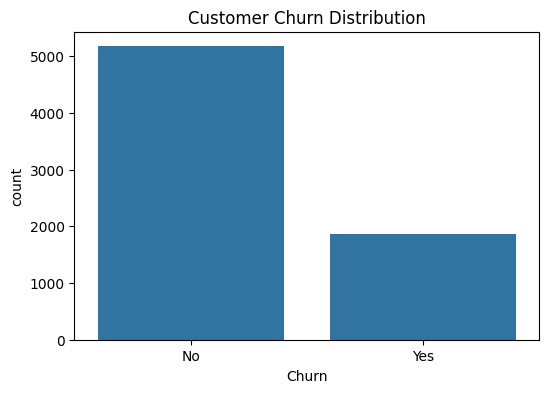

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')

plt.show()

OBSERVATIONS:

- Approximately 27% of customers have churned, while 73% remain active.
- Although retained customers form the majority, a 27% churn rate is significantly high for a subscription-based business.
- This suggests substantial customer attrition and potential revenue leakage.
- The company likely needs stronger retention strategies focused on reducing customer exits.

In [31]:
tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'])
tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,1149,1037
13-24 Months,730,294
25-48 Months,1269,325
49+ Months,2026,213


In [32]:
tenure_churn_pct = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index').round(2) * 100
tenure_churn_pct

Churn,No,Yes
TenureGroup,,
0-12 Months,53.0,47.0
13-24 Months,71.0,29.0
25-48 Months,80.0,20.0
49+ Months,90.0,10.0


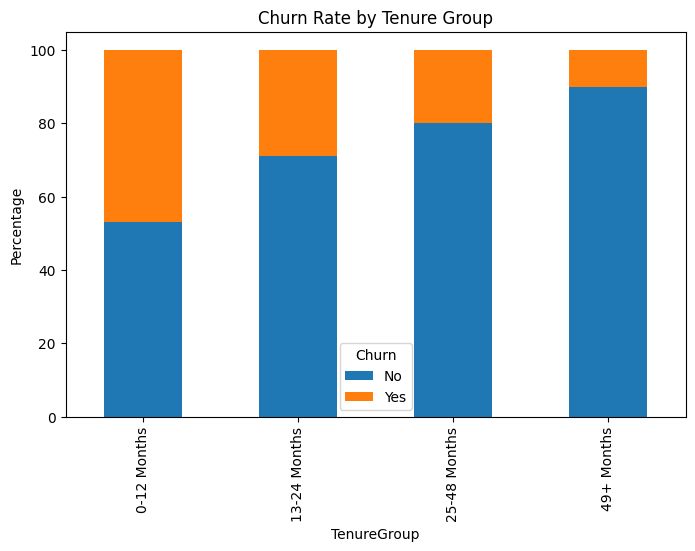

In [33]:
tenure_churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Churn Rate by Tenure Group')
plt.ylabel('Percentage')
plt.show()

In [34]:
contact_type_churn = pd.crosstab(df['Contract'], df['Churn'])
contact_type_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [35]:
contract_type_churn_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(2) * 100
contract_type_churn_pct

Churn,No,Yes
Contract,,
Month-to-month,57.0,43.0
One year,89.0,11.0
Two year,97.0,3.0


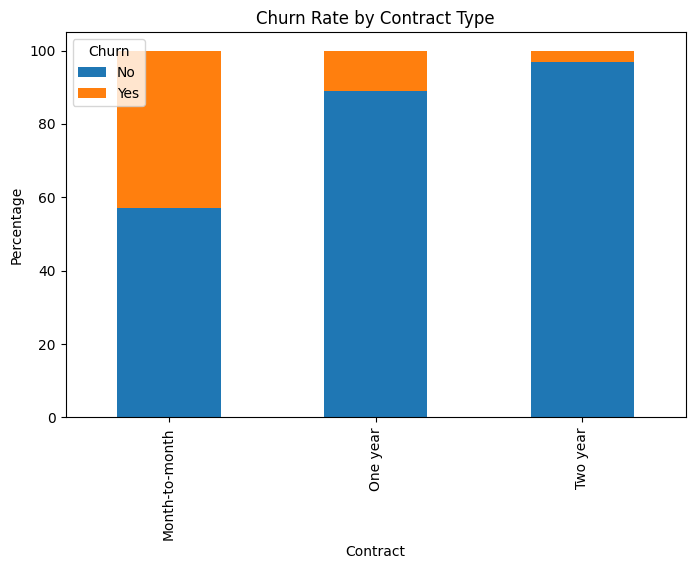

In [36]:
contract_type_churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.show()

Month-to-month customers exhibit significantly higher churn behavior, likely due to lower contractual commitment, higher price sensitivity, and reduced switching barriers compared to long-term contract customers.

In [37]:
total_services_churn = pd.crosstab(df['TotalServices'], df['Churn'])
total_services_churn

Churn,No,Yes
TotalServices,,
1,1126,138
2,593,266
3,466,380
4,613,352
5,633,289
6,676,232
7,524,152
8,346,49
9,197,11


In [38]:
total_services_churn_pct = pd.crosstab(df['TotalServices'], df['Churn'], normalize='index').round(2) * 100
total_services_churn_pct

Churn,No,Yes
TotalServices,,
1,89.0,11.0
2,69.0,31.0
3,55.0,45.0
4,64.0,36.0
5,69.0,31.0
6,74.0,26.0
7,78.0,22.0
8,88.0,12.0
9,95.0,5.0


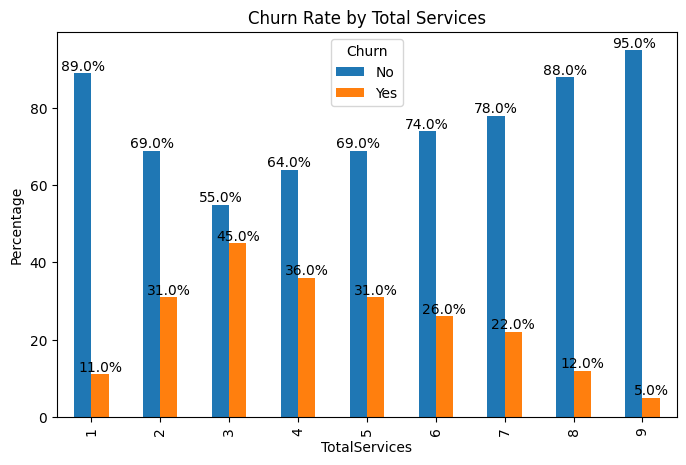

In [39]:

ax = total_services_churn_pct.plot(
    kind='bar',
    stacked=False,
    figsize=(8,5)
)


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge')


plt.title('Churn Rate by Total Services')
plt.ylabel('Percentage')
plt.show()


In [40]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [41]:
df['MonthlyChargeGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[18.25, 35.50, 89.85, 118.75],
    labels=['Low-Paying', 'Medium-Tier', 'Premium'],
    include_lowest=True
)
df[['MonthlyCharges', 'MonthlyChargeGroup']].head(10)

,MonthlyCharges,MonthlyChargeGroup
0,29.85,Low-Paying
1,56.95,Medium-Tier
2,53.85,Medium-Tier
3,42.30,Medium-Tier
4,70.70,Medium-Tier
5,99.65,Premium
6,89.10,Medium-Tier
7,29.75,Low-Paying
8,104.80,Premium
9,56.15,Medium-Tier


In [42]:
monthly_charge_churn = pd.crosstab(df['MonthlyChargeGroup'], df['Churn'])
monthly_charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
Low-Paying,1564,198
Medium-Tier,2430,1093
Premium,1180,578


In [43]:
monthly_charge_churn_pct = pd.crosstab(df['MonthlyChargeGroup'], df['Churn'], normalize='index').round(2) * 100
monthly_charge_churn_pct

Churn,No,Yes
MonthlyChargeGroup,,
Low-Paying,89.0,11.0
Medium-Tier,69.0,31.0
Premium,67.0,33.0


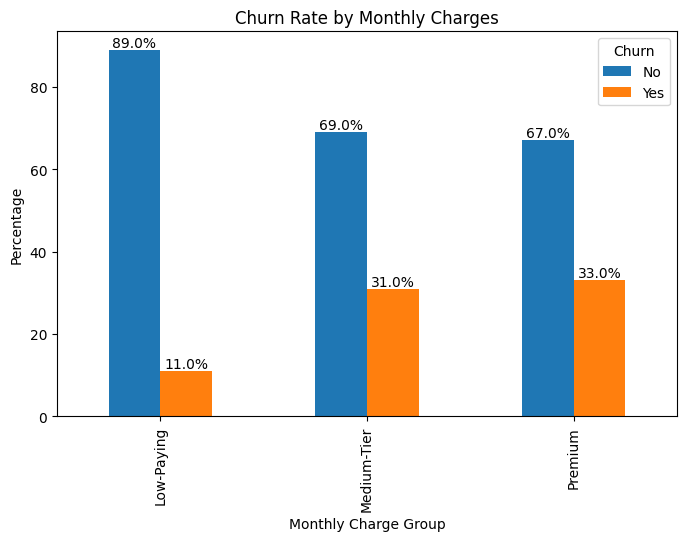

In [44]:
ax = monthly_charge_churn_pct.plot(
    kind='bar',
    stacked=False,
    figsize=(8,5)
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge')

plt.title('Churn Rate by Monthly Charges')
plt.ylabel('Percentage')
plt.xlabel('Monthly Charge Group')
plt.show()

OBSERVATIONS:

- Premium-tier customers exhibit the highest churn rate (~33%), followed closely by medium-tier customers (~31%).
- Low-paying customers demonstrate significantly stronger retention with only ~11% churn.
- This suggests that higher pricing alone does not guarantee customer retention and may increase sensitivity toward perceived product value.
- Customers paying premium pricing may have higher service expectations and stronger competitive awareness.
- Improving perceived value through bundled services, onboarding, and enhanced customer experience may help reduce premium-tier churn.

In [45]:
rev_contribution_total_services = df.groupby('TotalServices')['MonthlyCharges'].mean()
rev_contribution_total_services

TotalServices
1     20.268354
2     42.000873
3     61.700059
4     69.356010
5     78.726681
6     86.306553
7     93.642382
8     99.427215
9    104.632212
Name: MonthlyCharges, dtype: float64

In [46]:
rev_contribution_total_services_totalcharges = df.groupby('TotalServices')['TotalCharges'].mean()
rev_contribution_total_services_totalcharges

TotalServices
1     496.831052
2     761.406694
3     873.758511
4    1617.746528
5    2436.357809
6    3544.236013
7    4767.103254
8    5926.210253
9    6951.431490
Name: TotalCharges, dtype: float64

In [47]:
df['ChurnBinary'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [48]:
summary_table = df.groupby('TotalServices').agg(
    ChurnRate=('ChurnBinary', 'mean'),
    TotalChargesAvg=('TotalCharges', 'mean'),
    MonthlyChargesAvg=('MonthlyCharges', 'mean')
)
summary_table

,ChurnRate,TotalChargesAvg,MonthlyChargesAvg
TotalServices,,,
1,0.109177,496.831052,20.268354
2,0.309662,761.406694,42.000873
3,0.449173,873.758511,61.700059
4,0.364767,1617.746528,69.356010
5,0.313449,2436.357809,78.726681
6,0.255507,3544.236013,86.306553
7,0.224852,4767.103254,93.642382
8,0.124051,5926.210253,99.427215
9,0.052885,6951.431490,104.632212


In [49]:
summary_table['ChurnRate'] = (summary_table['ChurnRate'] * 100).round(2)

In [50]:
summary_table["MonthlyChargesAvg"] = summary_table["MonthlyChargesAvg"].round(2)

In [51]:
summary_table['TotalChargesAvg'] = summary_table['TotalChargesAvg'].round(2)

In [52]:
summary_table

,ChurnRate,TotalChargesAvg,MonthlyChargesAvg
TotalServices,,,
1,10.92,496.83,20.27
2,30.97,761.41,42.00
3,44.92,873.76,61.70
4,36.48,1617.75,69.36
5,31.34,2436.36,78.73
6,25.55,3544.24,86.31
7,22.49,4767.10,93.64
8,12.41,5926.21,99.43
9,5.29,6951.43,104.63


In [53]:
tenuregroup_summary_table = df.groupby('TenureGroup').agg(
    ChurnRate=('ChurnBinary', 'mean'),
    TotalChargesAvg=('TotalCharges', 'mean'),
    MonthlyChargesAvg=('MonthlyCharges', 'mean')
)

In [54]:
tenuregroup_summary_table['RetentionRate'] = (1 - tenuregroup_summary_table['ChurnRate']) * 100
tenuregroup_summary_table

,ChurnRate,TotalChargesAvg,MonthlyChargesAvg,RetentionRate
TenureGroup,,,,
0-12 Months,0.474382,275.229597,56.097781,52.561757
13-24 Months,0.287109,1126.257520,61.357275,71.289062
25-48 Months,0.203890,2390.451913,65.930552,79.611041
49+ Months,0.095132,4685.506364,73.945377,90.486824


In [55]:
tenuregroup_summary_table['ChurnRate'] = (tenuregroup_summary_table['ChurnRate'] * 100).round(2)

In [56]:
tenuregroup_summary_table['RetentionRate'] = tenuregroup_summary_table['RetentionRate'].round(2)
tenuregroup_summary_table

,ChurnRate,TotalChargesAvg,MonthlyChargesAvg,RetentionRate
TenureGroup,,,,
0-12 Months,47.44,275.229597,56.097781,52.56
13-24 Months,28.71,1126.257520,61.357275,71.29
25-48 Months,20.39,2390.451913,65.930552,79.61
49+ Months,9.51,4685.506364,73.945377,90.49


In [57]:
contract_summary_table = df.groupby('Contract').agg(
    ChurnRate=('ChurnBinary', 'mean'),
    TotalChargesAvg=('TotalCharges', 'mean'),
    MonthlyChargesAvg=('MonthlyCharges', 'mean')
)

In [58]:
contract_summary_table['RetentionRate'] = (1 - contract_summary_table['ChurnRate']).round(2) * 100

In [59]:
# 1. Divide both columns by 100 to fix the accidental double multiplication
contract_summary_table['ChurnRate'] = contract_summary_table['ChurnRate'] / 100
contract_summary_table['RetentionRate'] = contract_summary_table['RetentionRate'] / 100

# 2. Convert the negative values in RetentionRate to positive numbers
contract_summary_table['RetentionRate'] = contract_summary_table['RetentionRate'].abs()

# View the corrected table
contract_summary_table


,ChurnRate,TotalChargesAvg,MonthlyChargesAvg,RetentionRate
Contract,,,,
Month-to-month,0.004271,1369.254581,66.398490,0.57
One year,0.001127,3032.622878,65.048608,0.89
Two year,0.000283,3706.934336,60.770413,0.97


In [60]:
contract_summary_table.drop(columns=['RetentionRate'], inplace=True)

In [61]:
contract_summary_table['RetentionRate'] = 100 - contract_summary_table['ChurnRate']
contract_summary_table


,ChurnRate,TotalChargesAvg,MonthlyChargesAvg,RetentionRate
Contract,,,,
Month-to-month,0.004271,1369.254581,66.398490,99.995729
One year,0.001127,3032.622878,65.048608,99.998873
Two year,0.000283,3706.934336,60.770413,99.999717


In [62]:
conditions = [

    # Loyal Customers
    (
        (df['Contract'] == 'Two year') &
        (df['TotalServices'] >= 7) &
        (df['TenureGroup'] == '49+ Months')
    ),

    # High Risk Customers
    (
        (df['Contract'] == 'Month-to-month') &
        (df['TotalServices'] <= 3) &
        (df['MonthlyChargeGroup'].isin(['Medium-Tier', 'Premium']))
    ),

    # Medium Risk Customers
    (
        (df['Contract'] == 'One year') |
        (df['TotalServices'].between(4, 6))
    )
]

choices = [
    'Loyal',
    'High Risk',
    'Medium Risk'
]

df['Customer_Risk_Profile'] = np.select(
    conditions,
    choices,
    default='Medium Risk'
)

df[['customerID', 'Customer_Risk_Profile']].head(10)

,customerID,Customer_Risk_Profile
0,7590-VHVEG,Medium Risk
1,5575-GNVDE,Medium Risk
2,3668-QPYBK,Medium Risk
3,7795-CFOCW,Medium Risk
4,9237-HQITU,High Risk
5,9305-CDSKC,Medium Risk
6,1452-KIOVK,Medium Risk
7,6713-OKOMC,Medium Risk
8,7892-POOKP,Medium Risk
9,6388-TABGU,Medium Risk


In [63]:
df['Customer_Risk_Profile'].value_counts()

Customer_Risk_Profile
Medium Risk    5321
High Risk      1127
Loyal           595
Name: count, dtype: int64

In [64]:
risk_summary = df.groupby('Customer_Risk_Profile').agg(
    ChurnRate=('ChurnBinary', 'mean'),
    CustomerCount=('customerID', 'count')
)

risk_summary['ChurnRate'] = (risk_summary['ChurnRate'] * 100).round(2)
risk_summary

,ChurnRate,CustomerCount
Customer_Risk_Profile,,
High Risk,51.38,1127
Loyal,4.54,595
Medium Risk,23.74,5321


In [65]:
revenue_risk_summary = df.groupby('Customer_Risk_Profile').agg(
    MonthlyChargesAvg=('MonthlyCharges', 'mean'),
    TotalChargesAvg=('TotalCharges', 'mean')
)

revenue_risk_summary['MonthlyChargesAvg'] = revenue_risk_summary['MonthlyChargesAvg'].round(2)


In [66]:
revenue_risk_summary['TotalChargesAvg'] = revenue_risk_summary['TotalChargesAvg'].round(2)
revenue_risk_summary

,MonthlyChargesAvg,TotalChargesAvg
Customer_Risk_Profile,,
High Risk,62.73,655.32
Loyal,95.59,6503.09
Medium Risk,61.75,2151.53


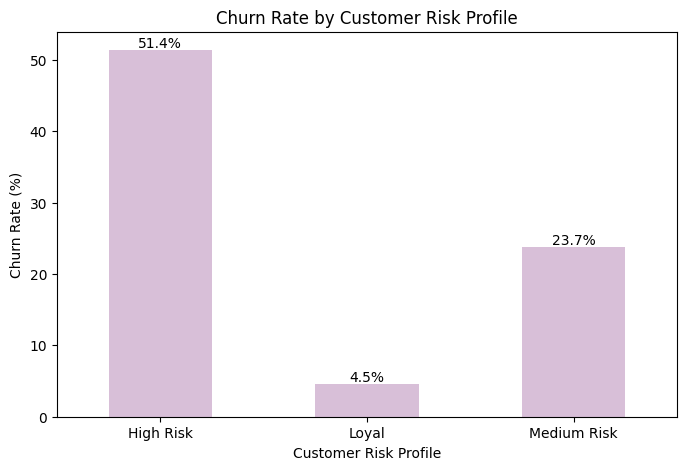

In [67]:
ax = risk_summary.plot(
    kind='bar',
    y='ChurnRate',
    legend=False,
    figsize=(8,5),
    color=['thistle']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge',)

plt.title('Churn Rate by Customer Risk Profile')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Customer Risk Profile')
plt.xticks(rotation=0)
plt.show()

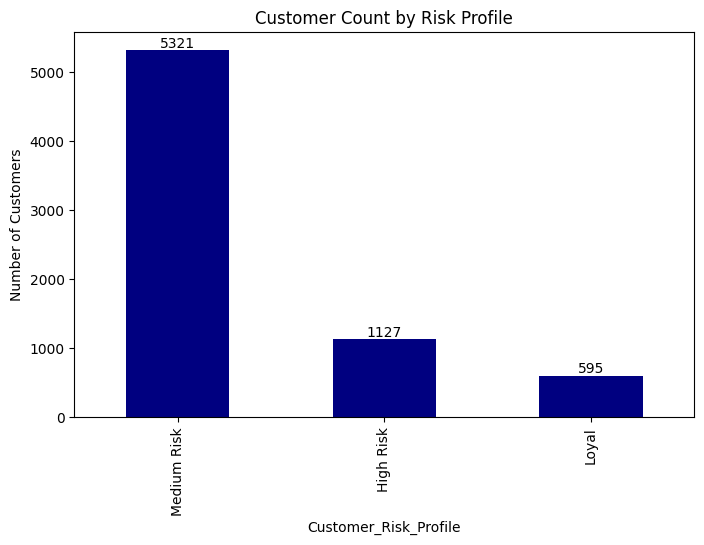

In [68]:
ax = df.Customer_Risk_Profile.value_counts().plot(
    kind='bar',
    figsize=(8,5),
    color=['navy']
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.title('Customer Count by Risk Profile')
plt.ylabel('Number of Customers')
plt.show()

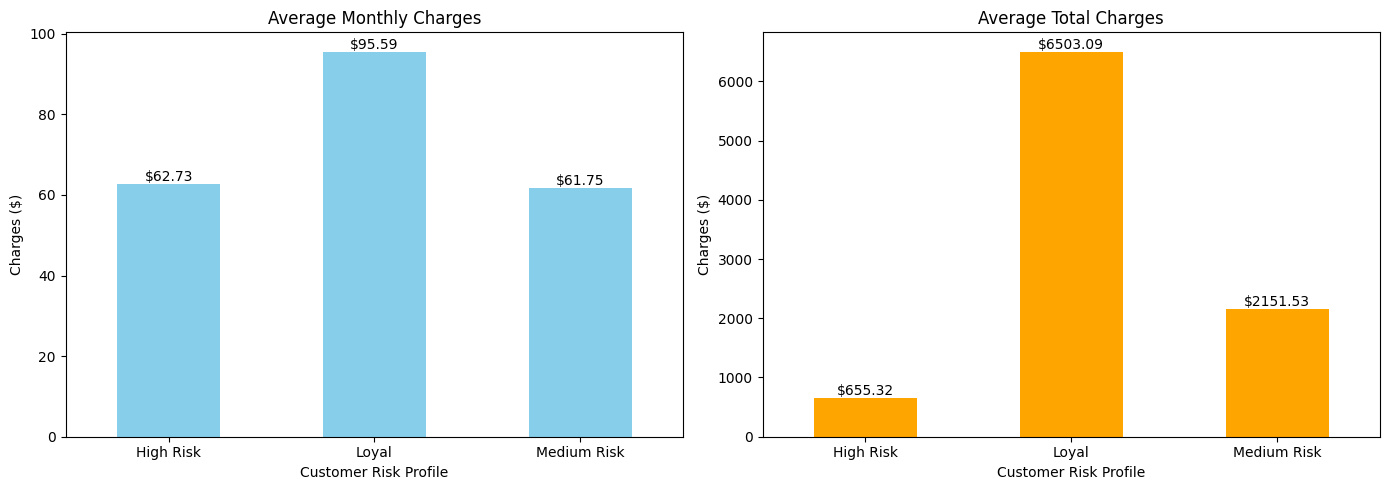

In [69]:
import matplotlib.pyplot as plt

# 1. Create a figure with 1 row and 2 columns of plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2. Plot Monthly Charges on the FIRST subplot (ax1)
revenue_risk_summary['MonthlyChargesAvg'].plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Average Monthly Charges')
ax1.set_ylabel('Charges ($)')
ax1.set_xlabel('Customer Risk Profile')
ax1.set_xticklabels(revenue_risk_summary.index, rotation=0)

# Add labels to the first plot
for container in ax1.containers:
    ax1.bar_label(container, fmt='$%.2f', label_type='edge')

# 3. Plot Total Charges on the SECOND subplot (ax2)
revenue_risk_summary['TotalChargesAvg'].plot(kind='bar', ax=ax2, color='orange')
ax2.set_title('Average Total Charges')
ax2.set_ylabel('Charges ($)')
ax2.set_xlabel('Customer Risk Profile')
ax2.set_xticklabels(revenue_risk_summary.index, rotation=0)

# Add labels to the second plot
for container in ax2.containers:
    ax2.bar_label(container, fmt='$%.2f', label_type='edge')

# 4. Adjust layout to prevent overlapping and show
plt.tight_layout()
plt.show()


In [70]:
df.to_csv('cleaned_telco_churn.csv', index=False)

In [71]:
import sqlite3

In [72]:
conn = sqlite3.connect('telco_churn.db')

In [73]:
df.to_sql(
    'telco_customers',
    conn,
    if_exists='replace',
    index=False
)

7043

In [74]:
query = "SELECT * FROM telco_customers LIMIT 5"

pd.read_sql(query, conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,TotalServices,MonthlyChargeGroup,ChurnBinary,Customer_Risk_Profile
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,0-12 Months,2,Low-Paying,0,Medium Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,25-48 Months,4,Medium-Tier,0,Medium Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,0-12 Months,4,Medium-Tier,1,Medium Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months,4,Medium-Tier,0,Medium Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,0-12 Months,2,Medium-Tier,1,High Risk


In [76]:
risk_summary.to_csv(
    'risk_profile_summary.csv',
    index=True
)

In [77]:
contract_summary_table.to_csv(
    'contract_summary.csv',
    index=True
)

In [78]:
tenuregroup_summary_table.to_csv(
    'tenure_lifecycle_summary.csv',
    index=True
)

In [79]:
revenue_risk_summary.to_csv(
    'revenue_leakage_risk_profile.csv',
    index=True
)

In [80]:
df.to_csv('final_telco_customer_analytics.csv', index=False)